# Laboratorio 04 - Arboles de Decision
## CC3074 - Mineria de Datos | Universidad del Valle de Guatemala

**Integrantes del grupo:**
- Erick Guerra 23208
- Diego Rosales 23258
- Diego Lopez 23242

**Dataset:** Airbnb Listings (`listings.RData`)

---
## Actividad 1 - Descarga y carga del conjunto de datos

In [4]:
from pathlib import Path
import pyreadr

rdata_path = Path('data/listings.RData')
dict_path = Path('data/Diccionario_Variables_Airbnb.pdf')

result = pyreadr.read_r(str(rdata_path))
df = result['listings']

print('Objeto cargado:', list(result.keys()))
print('Dimensiones del dataset:', df.shape)
print('Total de columnas:', len(df.columns))
print('Primeras 10 columnas:', df.columns[:10].tolist())

Objeto cargado: ['listings']
Dimensiones del dataset: (171748, 80)
Total de columnas: 80
Primeras 10 columnas: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id']


---
## Actividad 2 - EDA y preprocesamiento (version resumida)

Se presenta un EDA enfocado en hallazgos utiles para prediccion de precio y un preprocesamiento breve para dejar los datos listos para modelado.

Observaciones: 171,748 | Variables: 83

Top 8 variables con faltantes:


,faltantes,porcentaje
calendar_updated,171748,100.00
estimated_revenue_l365d,95502,55.61
price_num,95502,55.61
price,89381,52.04
neighbourhood_group_cleansed,50683,29.51
review_scores_checkin,40324,23.48
review_scores_location,40328,23.48
review_scores_value,40328,23.48


Duplicados exactos: 0 | IDs duplicados: 0

Resumen de price_num:


,price_num
count,76246.000000
mean,750.509220
std,4250.606945
min,8.000000
50%,193.000000
75%,326.000000
95%,1034.000000
99%,20000.000000
max,50123.000000


Outliers por IQR: 9.85%


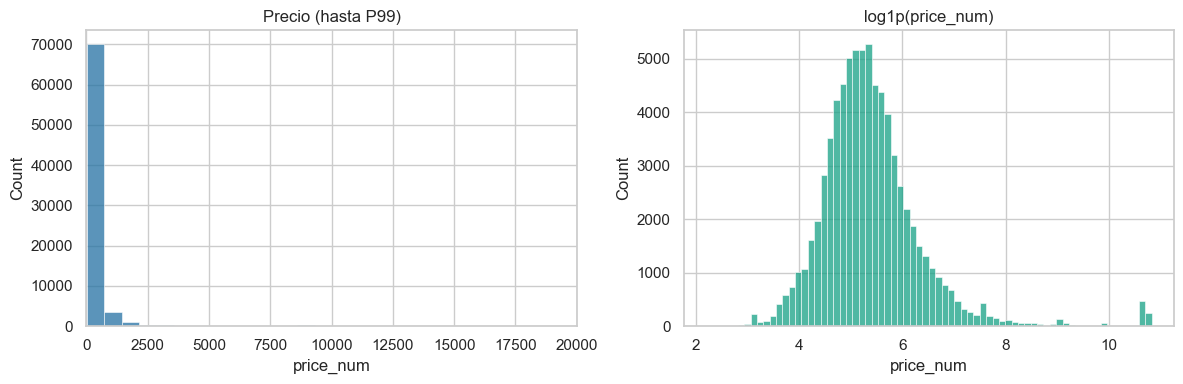


Precio mediano por room_type:


,conteo,mediana
room_type,,
Hotel room,649,40000.0
Entire home/apt,65709,205.0
Private room,9673,85.0
Shared room,215,42.0


Top 5 vecindarios por mediana de precio (min 200 registros):


,conteo,mediana
neighbourhood_cleansed,,
Ewa,827,461.0
Narragansett,758,428.0
Middletown,450,403.5
Koloa-Poipu,1651,383.0
Lahaina,5214,375.5


In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')

df_eda = df.copy()

def parse_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r'[$,]', '', regex=True).str.strip(),
        errors='coerce',
    )

# 1) Conversiones basicas para analisis
if 'price' in df_eda.columns:
    df_eda['price_num'] = parse_money(df_eda['price'])

for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df_eda.columns:
        df_eda[f'{col}_num'] = pd.to_numeric(
            df_eda[col].astype(str).str.replace('%', '', regex=False),
            errors='coerce',
        )

for col in ['last_scraped', 'host_since', 'first_review', 'last_review']:
    if col in df_eda.columns:
        df_eda[col] = pd.to_datetime(df_eda[col], errors='coerce')

# 2) Calidad de datos
n_rows, n_cols = df_eda.shape
print(f'Observaciones: {n_rows:,} | Variables: {n_cols}')

missing_table = (
    df_eda.isna().sum().to_frame('faltantes')
    .assign(porcentaje=lambda t: (t['faltantes'] / n_rows * 100).round(2))
    .query('faltantes > 0')
    .sort_values('porcentaje', ascending=False)
)
print('\nTop 8 variables con faltantes:')
display(missing_table.head(8))

dup_rows = df_eda.duplicated().sum()
dup_id = df_eda['id'].duplicated().sum() if 'id' in df_eda.columns else np.nan
print(f'Duplicados exactos: {dup_rows:,} | IDs duplicados: {dup_id:,}')

# 3) Comportamiento de precio y senales utiles
if 'price_num' in df_eda.columns:
    price_series = df_eda['price_num'].dropna()
    price_stats = price_series.describe(percentiles=[0.5, 0.75, 0.95, 0.99])
    print('\nResumen de price_num:')
    display(price_stats.to_frame('price_num'))

    q1, q3 = price_series.quantile([0.25, 0.75])
    outlier_rate = ((price_series > (q3 + 1.5 * (q3 - q1))).mean() * 100)
    print(f'Outliers por IQR: {outlier_rate:.2f}%')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(price_series, bins=70, color='#2471a3', ax=axes[0])
    axes[0].set_xlim(0, price_series.quantile(0.99))
    axes[0].set_title('Precio (hasta P99)')

    sns.histplot(np.log1p(price_series), bins=70, color='#16a085', ax=axes[1])
    axes[1].set_title('log1p(price_num)')
    plt.tight_layout()
    plt.show()

if {'room_type', 'price_num'}.issubset(df_eda.columns):
    room_summary = (
        df_eda.groupby('room_type')['price_num']
        .agg(conteo='count', mediana='median')
        .sort_values('mediana', ascending=False)
    )
    print('\nPrecio mediano por room_type:')
    display(room_summary)

if {'neighbourhood_cleansed', 'price_num'}.issubset(df_eda.columns):
    neigh_summary = (
        df_eda.groupby('neighbourhood_cleansed')['price_num']
        .agg(conteo='count', mediana='median')
        .query('conteo >= 200')
        .sort_values('mediana', ascending=False)
        .head(5)
    )
    print('Top 5 vecindarios por mediana de precio (min 200 registros):')
    display(neigh_summary)

In [14]:
candidate_features = [
    'room_type', 'property_type', 'neighbourhood_cleansed',
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
    'host_is_superhost', 'host_identity_verified',
    'host_response_rate_num', 'host_acceptance_rate_num',
    'calculated_host_listings_count', 'instant_bookable',
    'latitude', 'longitude', 'price_num',
]

selected_cols = [c for c in candidate_features if c in df_eda.columns]
model_df = df_eda[selected_cols].copy()
before_rows = model_df.shape[0]

# Limpieza de objetivo y recorte de extremos
model_df = model_df[model_df['price_num'].notna()].copy()
p99_price = model_df['price_num'].quantile(0.99)
model_df = model_df[model_df['price_num'] <= p99_price].copy()

num_cols = [c for c in model_df.select_dtypes(include=np.number).columns if c != 'price_num']
cat_cols = model_df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in cat_cols:
    model_df[col] = model_df[col].astype(str).replace('nan', 'SinDato')

X = model_df.drop(columns=['price_num'])
y = model_df['price_num']
X_encoded = pd.get_dummies(X, drop_first=True)

print('Resumen del preprocesamiento:')
print(f'Filas iniciales: {before_rows:,}')
print(f'Filas finales: {len(model_df):,}')
print(f'Numericas imputadas: {len(num_cols)} | Categoricas codificadas: {len(cat_cols)}')
print(f'Dimension final de X: {X_encoded.shape}')

Resumen del preprocesamiento:
Filas iniciales: 171,748
Filas finales: 75,531
Numericas imputadas: 13 | Categoricas codificadas: 8
Dimension final de X: (75531, 520)


### Conclusiones (resumen corto)
1. El dataset tiene buen volumen, pero faltantes importantes en varias columnas; se requiere seleccion cuidadosa de variables.
2. `price` debio convertirse a `price_num`; la distribucion es asimetrica y con outliers, por lo que se justifica control de extremos y referencia logaritmica.
3. `room_type`, ubicacion (`neighbourhood_cleansed`) y capacidad del alojamiento son las senales mas utiles para predecir precio.
4. El preprocesamiento aplicado (filtro de precio nulo, imputacion, recorte por P99 y one-hot encoding) deja una base consistente para entrenar arboles de decision.
5. Resultado: matriz modelable lista para train/test con 75,531 filas despues de limpieza.